In [ ]:
# Load the main packages for data analysis, plotting, and file handling
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


# Sales Data Cleaning
This notebook loads raw sales and returns data, checks the tables, cleans columns and types, validates the results, and saves a clean version for later use.

In [ ]:
# Set file and folder paths relative to the project root
curr_dir = os.getcwd()
root = os.path.abspath(os.path.join(curr_dir,'..'))
raw_data_path = os.path.join(root,'data','raw')
processed_data_path = os.path.join(root,'data','processed')
data_file_name = 'sales_data.xls'

### Load raw data
Read the sales and returns sheets, then confirm the files are available and loaded.

In [3]:
try:
    orders = pd.read_excel(os.path.join(raw_data_path,data_file_name),sheet_name = 'Orders')
    print("Orders data loaded successfully.")

    returns = pd.read_excel(os.path.join(raw_data_path,data_file_name),sheet_name = 'Returns')
    print("Returns data loaded successfully.")

except FileNotFoundError as e:
    print(f"File not found: {e}")

except Exception as e:
    print(f"An error occurred: {e}")


WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
Orders data loaded successfully.
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
Returns data loaded successfully.


## Initial data inspection
Look at the basic shape, sample rows, and summary information for the orders data.

In [ ]:
# View the number of rows and columns in the orders table
orders.shape

(9994, 21)

In [ ]:
# Show the first two records to check the columns and values
orders.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [ ]:
# Display summary information about the orders table
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9983 non-null   float64       
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
# Review numeric statistics for orders
orders.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2017-04-30 05:17:08.056834048,2017-05-04 04:17:20.304182528,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2016-05-23 00:00:00,2016-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2018-05-14 00:00:00,2018-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


### Handle missing values
Remove rows that still have missing values so the cleaned dataset is complete.

In [8]:
orders.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

### Standardize column names
Make the column names consistent by removing spaces and dashes.

In [9]:
orders.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [ ]:
# Drop rows that still contain null values after the initial check
orders.dropna(inplace = True)

In [11]:
orders.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
# Clean up order column names so they are consistent and easier to use
orders.columns = orders.columns.str.title()
orders.columns = orders.columns.str.replace(' ', "")
orders.columns = orders.columns.str.replace('-', "")

print(orders.columns)

Index(['RowId', 'OrderId', 'OrderDate', 'ShipDate', 'ShipMode', 'CustomerId',
       'CustomerName', 'Segment', 'Country', 'City', 'State', 'PostalCode',
       'Region', 'ProductId', 'Category', 'SubCategory', 'ProductName',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [ ]:
# Clean up return column names using the same rules
returns.columns = returns.columns.str.title()
returns.columns = returns.columns.str.replace(' ', "")
returns.columns = returns.columns.str.replace('-', "")

print(returns.columns)

Index(['Returned', 'OrderId'], dtype='object')


In [14]:
returns.head(2)

,Returned,OrderId
0,Yes,CA-2015-100762
1,Yes,CA-2015-100762


## Data type cleanup
Fix the main column types before validation so analysis is more reliable.

In [16]:
returns.describe()

,Returned,OrderId
count,800,800
unique,1,296
top,Yes,CA-2018-100111
freq,800,14


In [17]:
returns.isnull().sum()

Returned    0
OrderId     0
dtype: int64

In [18]:
returns.dtypes

Returned    object
OrderId     object
dtype: object

### Review return data
Inspect the returns table before merging it with orders.

## Data validation checks
Use simple checks to confirm profit, discount, shipping time, and returns data are correct.

In [ ]:
categorical_cols = [
    "ShipMode", "Segment", "Country", "City", "State",
    "Region", "Category", "SubCategory"
]

# Convert these columns to categorical data for cleaner analysis
for col in categorical_cols:
    orders[col] = orders[col].astype("category")


In [ ]:
# Drop unneeded identifiers that do not help with analysis
orders.drop(columns=["RowId"], inplace=True)

### Validation steps
Check profit, discount, shipping time, and return flags to make sure the cleaned data is trustworthy.

### Negative profit check
Find orders with negative profit to see if there are returns or pricing problems.

In [23]:
loss_orders = orders[orders["Profit"] < 0]

print("Total Loss Orders:", loss_orders.shape[0])
print("Total Loss Amount:", loss_orders["Profit"].sum())

Total Loss Orders: 1871
Total Loss Amount: -156131.2857


### Discount distribution
Review how the discount values are spread across orders.

In [24]:
print(orders["Discount"].value_counts().sort_index())


Discount
0.00    4787
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64


### Shipping time analysis
Calculate how long shipping took so we can detect slow deliveries.

In [25]:
orders["Shipping Days"] = (orders["ShipDate"] - orders["OrderDate"]).dt.days

orders["Shipping Days"].describe()

count    9983.000000
mean        3.958530
std         1.748424
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

### Merge returns with orders
Prepare the return flag so we can see which orders were sent back.

In [ ]:
# Remove duplicate returns so each order only appears once
returns = returns.drop_duplicates(subset=["OrderId"])

In [ ]:
# Create a flag showing whether an order was returned
returns["Returned"] = 1

# Merge returns with all orders using the order identifier
df = orders.merge(returns, on="OrderId", how="left")

# Fill missing values with 0 for non-returned orders
df["Returned"] = df["Returned"].fillna(0).astype(int)

# Verify the counts of returned vs non-returned orders
print(df["Returned"].value_counts())

Returned
0    9183
1     800
Name: count, dtype: int64


In [28]:
return_rate = df["Returned"].mean() * 100
print(f"Return Rate: {return_rate:.2f}%")


Return Rate: 8.01%


In [29]:
returns.shape

(296, 2)

In [30]:
orders.shape

(9983, 21)

In [34]:
returns.duplicated().sum()

np.int64(0)

In [35]:
df.duplicated().sum()

np.int64(1)

In [39]:
df.drop_duplicates(inplace = True)

In [41]:
df.duplicated().sum()


np.int64(0)

In [47]:
df.shape

(9982, 22)

In [43]:
df.head()

,OrderId,OrderDate,ShipDate,ShipMode,CustomerId,CustomerName,Segment,Country,City,State,...,ProductId,Category,SubCategory,ProductName,Sales,Quantity,Discount,Profit,Shipping Days,Returned
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,0
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,0
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,0
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,0
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,0


In [45]:
df[9000:9500]

,OrderId,OrderDate,ShipDate,ShipMode,CustomerId,CustomerName,Segment,Country,City,State,...,ProductId,Category,SubCategory,ProductName,Sales,Quantity,Discount,Profit,Shipping Days,Returned
9001,CA-2016-102855,2016-04-05,2016-04-06,Same Day,JF-15415,Jennifer Ferguson,Consumer,United States,Spokane,Washington,...,OFF-AR-10002467,Office Supplies,Art,Dixon Ticonderoga Pencils,23.84,8,0.0,6.4368,1,0
9002,CA-2018-107825,2018-11-18,2018-11-18,Same Day,NB-18655,Nona Balk,Corporate,United States,Milwaukee,Wisconsin,...,OFF-ST-10001321,Office Supplies,Storage,"Decoflex Hanging Personal Folder File, Blue",92.52,6,0.0,24.9804,0,1
9003,CA-2018-107825,2018-11-18,2018-11-18,Same Day,NB-18655,Nona Balk,Corporate,United States,Milwaukee,Wisconsin,...,OFF-ST-10000777,Office Supplies,Storage,"Companion Letter/Legal File, Black",37.76,1,0.0,10.5728,0,1
9004,CA-2018-107825,2018-11-18,2018-11-18,Same Day,NB-18655,Nona Balk,Corporate,United States,Milwaukee,Wisconsin,...,OFF-LA-10003720,Office Supplies,Labels,Avery 487,7.38,2,0.0,3.4686,0,1
9005,CA-2018-107825,2018-11-18,2018-11-18,Same Day,NB-18655,Nona Balk,Corporate,United States,Milwaukee,Wisconsin,...,FUR-FU-10000206,Furniture,Furnishings,"GE General Purpose, Extra Long Life, Showcase ...",5.82,2,0.0,2.7354,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9496,CA-2015-149104,2015-04-05,2015-04-07,Second Class,RD-19900,Ruben Dartt,Consumer,United States,Dearborn Heights,Michigan,...,OFF-AR-10002952,Office Supplies,Art,Stanley Contemporary Battery Pencil Sharpeners,26.70,2,0.0,7.4760,2,0
9497,CA-2015-149104,2015-04-05,2015-04-07,Second Class,RD-19900,Ruben Dartt,Consumer,United States,Dearborn Heights,Michigan,...,OFF-BI-10004209,Office Supplies,Binders,"Fellowes Twister Kit, Gray/Clear, 3/pkg",40.20,5,0.0,18.0900,2,0
9498,CA-2015-149104,2015-04-05,2015-04-07,Second Class,RD-19900,Ruben Dartt,Consumer,United States,Dearborn Heights,Michigan,...,OFF-AR-10004685,Office Supplies,Art,Binney & Smith Crayola Metallic Colored Pencil...,13.89,3,0.0,4.5837,2,0
9499,CA-2015-149104,2015-04-05,2015-04-07,Second Class,RD-19900,Ruben Dartt,Consumer,United States,Dearborn Heights,Michigan,...,OFF-ST-10000991,Office Supplies,Storage,Space Solutions HD Industrial Steel Shelving.,689.82,6,0.0,20.6946,2,0


## Export cleaned data
Save the final cleaned dataset so it can be used in later analysis or modeling.

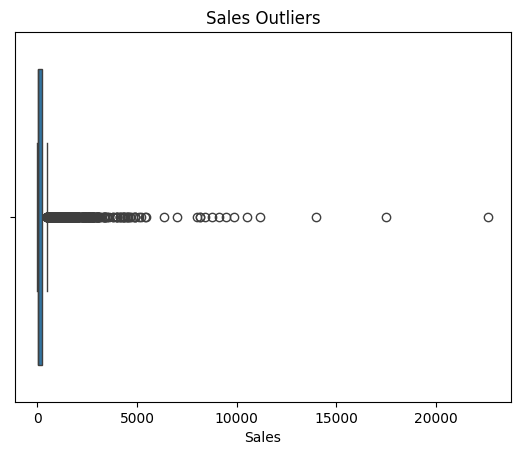

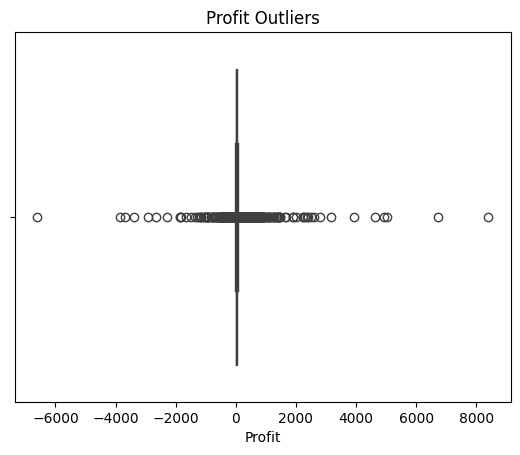

In [ ]:
plt.figure()
sns.boxplot(x=orders["Sales"])
plt.title("Sales Outliers")
plt.show()

plt.figure()
sns.boxplot(x=orders["Profit"])
plt.title("Profit Outliers")
plt.show()

In [ ]:
# Write the cleaned dataset to the processed folder
df.to_csv(os.path.join(processed_data_path,"cleaned_df.csv"),index=False)

In [56]:
df.columns

Index(['OrderId', 'OrderDate', 'ShipDate', 'ShipMode', 'CustomerId',
       'CustomerName', 'Segment', 'Country', 'City', 'State', 'PostalCode',
       'Region', 'ProductId', 'Category', 'SubCategory', 'ProductName',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days', 'Returned'],
      dtype='object')

In [60]:
print(df["Returned"].value_counts())

return_rate = df["Returned"].mean() * 100
print(f"Return Rate: {return_rate:.2f}%")

print("Unique Order IDs in Returns:", returns["OrderId"].nunique())

Returned
0    9182
1     800
Name: count, dtype: int64
Return Rate: 8.01%
Unique Order IDs in Returns: 296
